线性回归

1线性回归的从零开始实现

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

构造是数据集

In [2]:
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))  # 生成特征矩阵
    y = torch.matmul(X, w) + b                     # 计算无噪声的y
    y += torch.normal(0, 0.01, y.shape)            # 添加高斯噪声
    return X, y.reshape((-1, 1))                   # 返回特征和标签（标签转为列向量）
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

查看样本

In [3]:
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([ 1.1814, -1.2127]) 
label: tensor([10.6842])


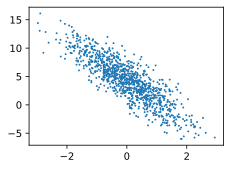

In [4]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),
               labels.detach().numpy(),1);

定义读取小批量函数

In [ ]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)       # 总样本数
    indices = list(range(num_examples)) # 生成样本索引列表 [0,1,...,999]
    random.shuffle(indices)            # 随机打乱索引，保证样本顺序随机
    # 按 batch_size 分批取数据
    for i in range(0, num_examples, batch_size):
        # 取当前批次的索引，最后一批可能不足 batch_size，用 min 保证不越界
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        # 生成器返回当前批次的特征和标签
        yield features[batch_indices], labels[batch_indices]
batch_size = 10  # 每个小批量包含10个样本
# 遍历迭代器，获取小批量数据
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)  # 打印当前批次的特征和标签
    break               # 只打印第一批，方便查看

初始化模型参数

In [7]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

定义模型

In [8]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

定义损失函数

In [10]:
def squared_loss(y_hat, y):
    """均方损失。"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

定义优化算法

In [11]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降。"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

训练过程

In [12]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.039935
epoch 2, loss 0.000157
epoch 3, loss 0.000049


比较真实参数和通过训练学到的参数来评估训练的成功程度

In [13]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0004, -0.0014], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0006], grad_fn=<RsubBackward1>)


2线性回归的简洁实现

In [14]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [15]:
def load_array(data_arrays, batch_size, is_train=True):  
    """构造一个PyTorch数据迭代器。"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))

[tensor([[-1.0965, -0.6545],
         [-0.2587,  1.2523],
         [ 0.3946,  0.2122],
         [-1.9334, -1.3233],
         [ 0.0095, -0.0742],
         [-0.8126, -1.3971],
         [ 0.6574,  1.0785],
         [-0.0112, -1.4515],
         [ 0.3746,  1.7497],
         [ 1.0503,  2.8751]]),
 tensor([[ 4.2417],
         [-0.5564],
         [ 4.2737],
         [ 4.8233],
         [ 4.4801],
         [ 7.3167],
         [ 1.8461],
         [ 9.1136],
         [-1.0095],
         [-3.4810]])]

使用预定好的层

In [17]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

初始化参数

In [18]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

计算均方误差用MSELoss类

In [19]:
loss=nn.MSELoss()

In [20]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

开始训练

In [21]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000208
epoch 2, loss 0.000102
epoch 3, loss 0.000101


In [22]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([ 0.0005, -0.0002])
b的估计误差： tensor([-0.0006])
